In [2]:
!pip install opencv-python

In [3]:
!python -m pip install --upgrade pip

In [4]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import kagglehub

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping
)

from tensorflow.keras.utils import to_categorical

C:\Users\sumit\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
path = kagglehub.dataset_download(
    "dmtrrmnv/clean-bone-fracture"
)

print("Dataset Downloaded At:\n")
print(path)

Dataset Downloaded At:

C:\Users\sumit\.cache\kagglehub\datasets\dmtrrmnv\clean-bone-fracture\versions\5


In [10]:
from tensorflow.keras.applications import EfficientNetB0

base_model = EfficientNetB0(

    weights='imagenet',

    include_top=False,

    input_shape=(64,64,3)
)

In [11]:
base_path = os.path.join(path, "data")

train_img = os.path.join(
    base_path,
    "train",
    "images"
)

train_lbl = os.path.join(
    base_path,
    "train",
    "labels"
)

val_img = os.path.join(
    base_path,
    "valid",
    "images"
)

val_lbl = os.path.join(
    base_path,
    "valid",
    "labels"
)

test_img = os.path.join(
    base_path,
    "test",
    "images"
)

test_lbl = os.path.join(
    base_path,
    "test",
    "labels"
)

In [12]:
print("\nTrain Images:",
      len(os.listdir(train_img)))

print("Validation Images:",
      len(os.listdir(val_img)))

print("Test Images:",
      len(os.listdir(test_img)))



Train Images: 1851
Validation Images: 377
Test Images: 134


In [13]:
def load_data(
    image_path,
    label_path,
    img_size=(64,64)
):

    images = []
    labels = []

    image_files = sorted(
        os.listdir(image_path)
    )

    label_files = sorted(
        os.listdir(label_path)
    )

    for img_file, lbl_file in zip(
        image_files,
        label_files
    ):

        # Read Image
        img = cv2.imread(
            os.path.join(
                image_path,
                img_file
            )
        )

        if img is None:
            continue

        # Resize
        img = cv2.resize(
            img,
            img_size
        )

        # Normalize
        img = img / 255.0

        images.append(img)

        # Read Label
        lbl = pd.read_csv(

            os.path.join(
                label_path,
                lbl_file
            ),

            header=None,

            sep=' '
        )

        label = int(
            lbl.iloc[0,0]
        )

        labels.append(label)

    return (
        np.array(images),
        np.array(labels)
    )


In [14]:
X_train, y_train = load_data(
    train_img,
    train_lbl
)

X_val, y_val = load_data(
    val_img,
    val_lbl
)

X_test, y_test = load_data(
    test_img,
    test_lbl
)


In [15]:
print("\nTraining Shape:",
      X_train.shape)

print("Validation Shape:",
      X_val.shape)

print("Testing Shape:",
      X_test.shape)


Training Shape: (1851, 64, 64, 3)
Validation Shape: (377, 64, 64, 3)
Testing Shape: (134, 64, 64, 3)


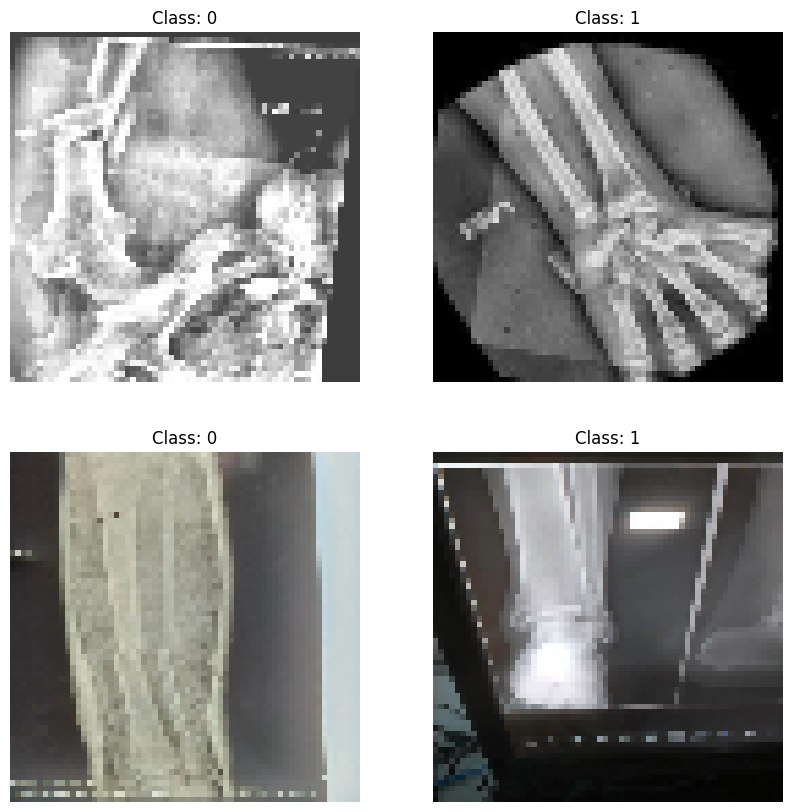

In [16]:
plt.figure(figsize=(10,10))

for i in range(4):

    index = random.randint(
        0,
        len(X_train)-1
    )

    plt.subplot(2,2,i+1)

    plt.imshow(X_train[index])

    plt.title(
        f"Class: {y_train[index]}"
    )

    plt.axis("off")

plt.show()


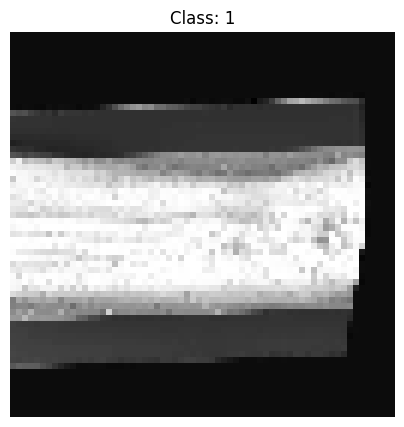

In [17]:
index = random.randint(
    0,
    len(X_test)-1
)

gray_img = cv2.cvtColor(

    (X_test[index]*255).astype("uint8"),

    cv2.COLOR_BGR2GRAY
)

plt.figure(figsize=(5,5))

plt.imshow(
    gray_img,
    cmap='gray'
)

plt.title(
    f"Class: {y_test[index]}"
)

plt.axis("off")

plt.show()

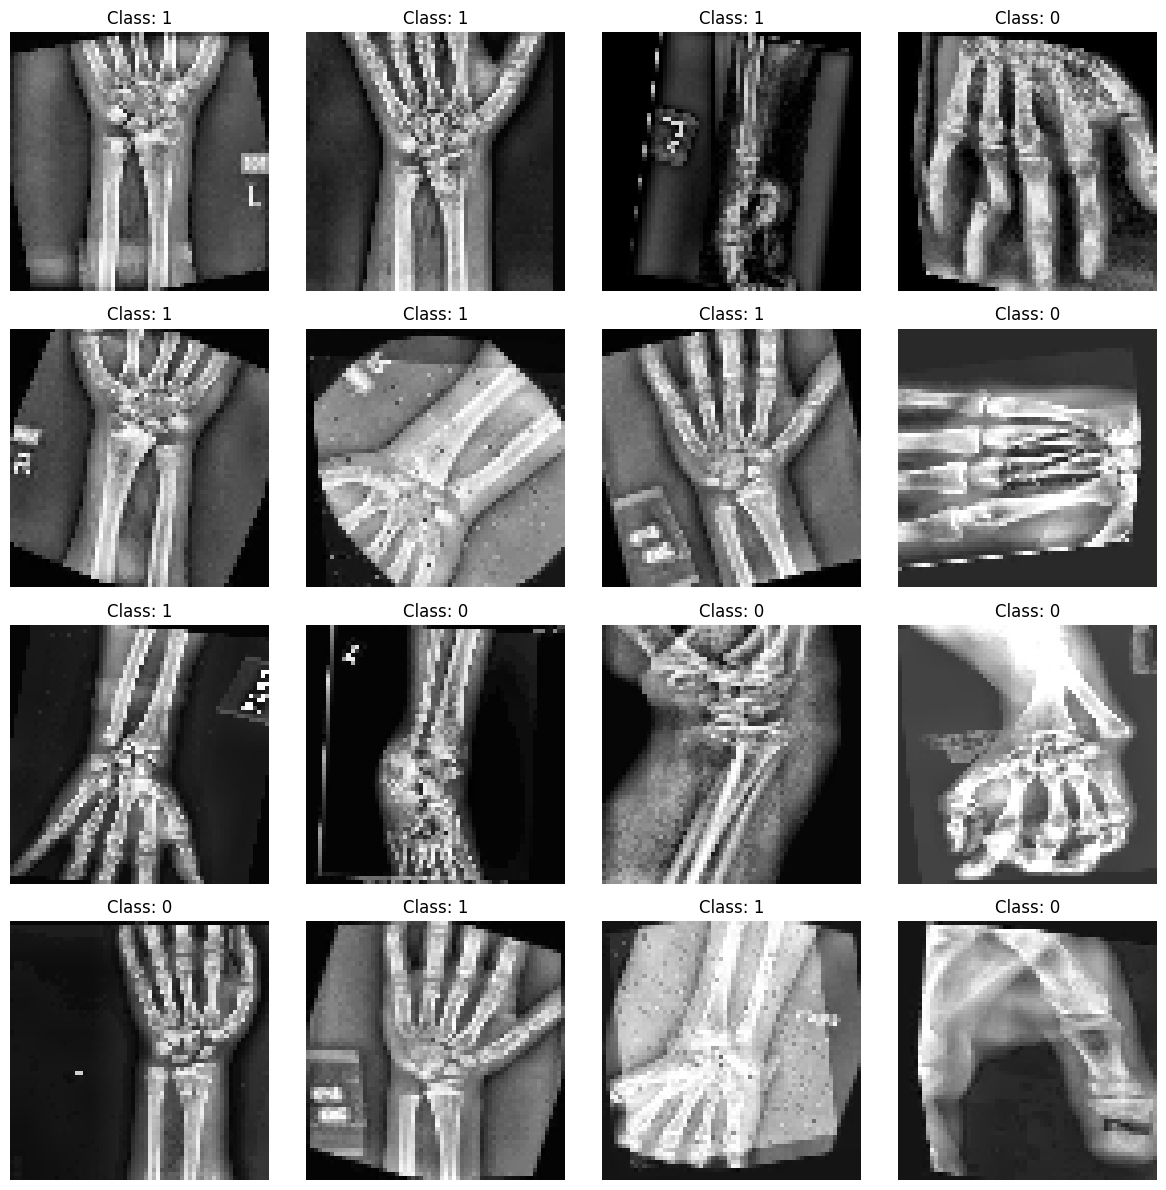

In [18]:
plt.figure(figsize=(12,12))

for i in range(16):

    plt.subplot(4,4,i+1)

    plt.imshow(X_train[i])

    plt.title(
        f"Class: {y_train[i]}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [19]:
model = Sequential([

    # Input Layer
    Input(shape=(64,64,3)),

# CNN BLOCK 1
    Conv2D(
        32,
        (3,3),
        activation='relu'
    ),

    BatchNormalization(),

    MaxPooling2D(
        pool_size=(2,2)
    ),

  
 # CNN BLOCK 2
   
    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    BatchNormalization(),

    MaxPooling2D(
        pool_size=(2,2)
    ),

# CNN BLOCK 3
   
    Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    BatchNormalization(),

    MaxPooling2D(
        pool_size=(2,2)
    ),


# FLATTEN

    Flatten(),

  
# DENSE LAYER
  
    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.5),

  
# OUTPUT LAYER
 
    Dense(
        2,
        activation='softmax'
    )
])

In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 62, 62, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 29, 29, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 12, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 12, 12, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         589,952 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 684,354 (2.61 MB)

 Trainable params: 683,906 (2.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [21]:
model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)


In [22]:
early_stop = EarlyStopping(

    monitor='val_loss',

    patience=5,

    restore_best_weights=True
)

In [38]:
history = model.fit(

    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=100,

    batch_size=16,
)

Epoch 1/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - accuracy: 0.9217 - loss: 0.2040 - val_accuracy: 0.8408 - val_loss: 0.5189
Epoch 2/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - accuracy: 0.9179 - loss: 0.1856 - val_accuracy: 0.8249 - val_loss: 0.4563
Epoch 3/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - accuracy: 0.9341 - loss: 0.1599 - val_accuracy: 0.7109 - val_loss: 1.2717
Epoch 4/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 9s 73ms/step - accuracy: 0.9546 - loss: 0.1045 - val_accuracy: 0.8355 - val_loss: 0.6209
Epoch 5/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 9s 73ms/step - accuracy: 0.9384 - loss: 0.1413 - val_accuracy: 0.8621 - val_loss: 0.4546
Epoch 6/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 9s 73ms/step - accuracy: 0.9427 - loss: 0.1526 - val_accuracy: 0.8355 - val_loss: 0.6557
Epoch 7/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - accuracy: 0.9498 - loss: 0.1405 - val_accuracy: 0.8568 - val_loss: 0.4904
Epoch 8/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - accuracy: 0.9660 - loss: 0.0889 - 

In [39]:
predictions = model.predict(
    X_test
)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


In [40]:
print("\nClassification Report:\n")

print(

    classification_report(

        y_test,

        predicted_classes
    )
)


Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.87      0.87        76
           1       0.83      0.84      0.84        58

    accuracy                           0.86       134
   macro avg       0.86      0.86      0.86       134
weighted avg       0.86      0.86      0.86       134



In [41]:
cm = confusion_matrix(
    y_test,
    predicted_classes
)

print("\nConfusion Matrix:\n")

print(cm)


Confusion Matrix:

[[66 10]
 [ 9 49]]


In [42]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("\nFinal Test Accuracy:")

print(accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8582 - loss: 1.2064

Final Test Accuracy:
0.858208954334259


In [44]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("\nFinal Test Accuracy:")

print(accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8582 - loss: 1.2064

Final Test Accuracy:
0.858208954334259
